# 08 — Training Techniques: Gradient Penalties and Spectral Normalization

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand *why* vanilla GAN training (example 05) breaks: vanishing D gradients and mode collapse
- Implement **WGAN-GP**: a Wasserstein critic with a gradient penalty
- Apply **spectral normalization** with `nn.utils.spectral_norm`
- Verify on a **real, multi-modal distribution** that the stabilized GAN matches the data — including that it has not mode-collapsed

## 🔗 Where this fits

**Builds on:** Course 10 — Unit 1, lesson 05 "Building and Training a Simple GAN" — the loop that broke; the fix needs `torch.autograd` from Course 08 (AIAT 122) — Unit 1, because the penalty is a constraint on the gradient itself (Course 03 (AIAT 113) — Unit 2).

**Used later in:** Course 10 — Unit 1, lesson 09, which trains a stabilised GAN against a VAE on equal terms.

---

## Introduction

The BCE minimax game from example 05 has two classic failure modes: when D gets too good its gradients to G vanish, and G can mode-collapse onto a few outputs. The most widely used fixes change *what D optimizes* and *how it is constrained*.

---

## 🌍 Why this lesson exists — "Are GANs Created Equal?"

The techniques in this notebook are real and widely deployed. What did *not* survive scrutiny is the claim that any particular one of them makes a GAN better. Lucic et al. (2018, arXiv 1711.10337) trained the major GAN variants under a **matched computational budget** and concluded: "we did not find evidence that any of the tested algorithms consistently outperforms the non-saturating GAN introduced in Goodfellow et al." Most reported improvements were compute and hyperparameter search wearing an architecture's name.

So learn WGAN-GP and spectral normalization as what they are — constraints that make an unstable optimisation tractable — and hold on to the habit this notebook models: verify with a measurement (mode coverage, mean, spread) rather than with a loss curve.

**What goes wrong without this:** with no Lipschitz constraint the critic's gradients either explode or vanish. The generator then gets a wildly wrong signal or no signal at all, and the usual symptom is a generator emitting one output forever while both loss curves look perfectly calm.


In [1]:
# WHAT/WHY: imports for the WGAN-GP demo — pure PyTorch, no downloads.
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
print(f'PyTorch {torch.__version__}')
print('Training Techniques: Gradient Penalties and Spectral Normalization')


PyTorch 2.13.0
Training Techniques: Gradient Penalties and Spectral Normalization


## The Two Techniques

**WGAN (Wasserstein GAN)** — replace D's "real or fake?" probability with an unconstrained **critic score**, and train G to maximize the critic's score on fakes. The resulting objective approximates the Wasserstein (earth-mover) distance between real and generated distributions — but only if the critic is **1-Lipschitz** (its gradients can't exceed norm 1).

**Gradient penalty (WGAN-GP)** — enforce the Lipschitz constraint softly: sample points *between* real and fake data, compute the critic's gradient there with `torch.autograd.grad`, and penalize `(‖∇‖ − 1)²`. This is the standard, robust way to train Wasserstein critics.

**Spectral normalization** — a harder architectural guarantee: divide each layer's weight matrix by its largest singular value, capping the layer's Lipschitz constant at 1. One-line application in PyTorch: `nn.utils.spectral_norm(nn.Linear(...))`.

We demo the two techniques separately below (stacking both on a tiny critic over-constrains it): first a full **WGAN-GP** training run checked against the target distribution's statistics, then a direct measurement of what **spectral normalization** does to a layer's largest singular value.


montgomery_911_calls: bundled 25,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.
Loaded 25,000 real 911 calls; dropped 25 impossible geocodes → 24,975 usable coordinates
Target distribution: standardised (lng, lat), mean [ 0. -0.], std [1. 1.]



                    real data           generated
mean      [ 0. -0.]        [ 0.122 -0.072]
std       [1. 1.]        [0.793 0.796]

Mode coverage (share of points per county quadrant):
  quadrant       SW     NW     SE     NE
  real        0.205  0.257  0.368  0.170
  generated   0.196  0.275  0.352  0.178
  max absolute gap: 0.017


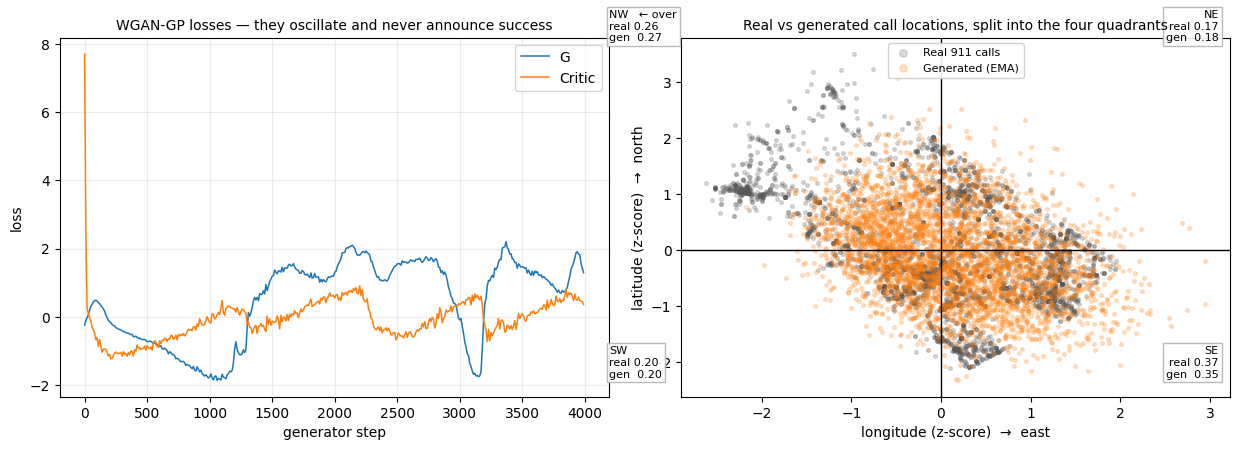


Read both checks. The generated cloud sits on the real one and puts mass
in all four quadrants — no mode collapse (largest share gap 0.017).
But the fit is not perfect, and the numbers say where: longitude spread is
right (0.793 vs 1.000) while latitude is under-dispersed (0.796 vs 1.000),
and the NW quadrant is over-weighted (0.275 vs a real 0.257). A 2-layer MLP trained for
4,000 steps under-covers the tails of a real, irregular geographic
distribution. That asymmetric shortfall is the honest result — and it is
the kind of thing a single invented Gaussian target can never reveal.


In [2]:
# WHAT/WHY: train a WGAN-GP (Wasserstein critic + gradient penalty) to
# reproduce a REAL, multi-modal distribution — the map of Montgomery County
# 911 call locations — then VERIFY it worked: compare the generated cloud's
# mean/std against the real data AND check mode coverage region by region,
# which is the failure a gradient penalty is meant to prevent.
# We evaluate an EMA (exponential moving average) copy of the generator —
# WGAN losses oscillate, and EMA weights are the standard stable snapshot
# (StyleGAN2 and diffusion models ship their EMA generators for the same reason).
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

torch.manual_seed(0)
latent_dim, batch_size = 8, 128

# ── REAL DATA: 911 dispatch coordinates ───────────────────────────────────
# HONEST NOTE: the full Montgomery County log is 123 MB / 663,522 calls and is NOT
#   in this repository. prefer="sample" reads the 25,000-row copy that ships with it
#   — one row in every 27, evenly spread over the same 2015-2020 window — so every
#   number printed below is reproducible on any machine, including Google Colab.
#   Put the full file in Course 04/datasets/raw/ and drop the prefer= argument to
#   train on all 663,522 coordinates.
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/...' only resolves when the kernel's
#       working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve("https://raw.githubusercontent.com/A-Alwabel/AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load
# -------------------------------------------------------------------------------------
df = load("montgomery_911_calls", prefer="sample", usecols=['lat', 'lng'])
n_raw = len(df)
# Real data has real defects: a handful of rows are geocoded outside the county
# (one lands in Alabama). Drop them, and say how many - do not hide the cleanup.
df = df[df['lat'].between(39.9, 40.6) & df['lng'].between(-75.9, -74.9)]
print(f'Loaded {n_raw:,} real 911 calls; dropped {n_raw - len(df)} impossible geocodes '
      f'→ {len(df):,} usable coordinates')

real_np = df[['lng', 'lat']].to_numpy()
mu, sd  = real_np.mean(0), real_np.std(0)
REAL    = torch.tensor((real_np - mu) / sd, dtype=torch.float32)   # standardised
print(f'Target distribution: standardised (lng, lat), '
      f'mean {REAL.mean(0).numpy().round(3)}, std {REAL.std(0).numpy().round(3)}')

def sample_real(n):
    """Draw a minibatch by resampling the REAL coordinate pool (with replacement)."""
    idx = torch.randint(0, len(REAL), (n,))
    return REAL[idx]

Generator = nn.Sequential(nn.Linear(latent_dim, 64), nn.ReLU(),
                          nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 2))
# Critic (not "discriminator"): raw score, NO Sigmoid — WGAN style
Critic = nn.Sequential(nn.Linear(2, 64), nn.LeakyReLU(0.2),
                       nn.Linear(64, 64), nn.LeakyReLU(0.2), nn.Linear(64, 1))
G_ema = copy.deepcopy(Generator)   # slow-moving average of G's weights

# WGAN-GP hyperparameters (Gulrajani et al.): Adam(0.5, 0.9), slower G than critic
opt_G = optim.Adam(Generator.parameters(), lr=5e-5, betas=(0.5, 0.9))
opt_D = optim.Adam(Critic.parameters(),    lr=2e-4, betas=(0.5, 0.9))

def gradient_penalty(critic, real, fake, lam=10.0):
    """WGAN-GP: penalize the critic's gradient norm on points interpolated
    between real and fake — softly enforcing the 1-Lipschitz constraint.
    The random alpha here is part of the ALGORITHM, not invented data."""
    alpha  = torch.rand(real.size(0), 1)
    interp = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    score  = critic(interp)
    grads  = torch.autograd.grad(score, interp,
                                 grad_outputs=torch.ones_like(score),
                                 create_graph=True)[0]
    return lam * ((grads.norm(2, dim=1) - 1) ** 2).mean()

# ── Storyboard capture: freeze the generator's output at chosen steps, always
# from the SAME 1,500 latent vectors, so we can watch the generated cloud find
# the county instead of only seeing where it ended up.
SNAPSHOT_STEPS = [0, 100, 400, 1000, 2000, 4000]
# Own generator: the storyboard must not disturb the training random stream.
snap_rng     = torch.Generator().manual_seed(7)
fixed_z_gp   = torch.randn(1500, latent_dim, generator=snap_rng)
snapshots_gp = []

# ── Training: 5 critic steps per generator step (standard WGAN schedule) ──
g_losses, d_losses = [], []
for step in range(4000):
    if step in SNAPSHOT_STEPS:                 # snapshot BEFORE this generator update
        with torch.no_grad():
            snapshots_gp.append((step, Generator(fixed_z_gp).numpy()))
    for _ in range(5):
        real = sample_real(batch_size)
        # torch.randn here is the LATENT NOISE z — the generator's input, and
        # the one place randomness genuinely belongs in a GAN.
        fake = Generator(torch.randn(batch_size, latent_dim)).detach()
        gp   = gradient_penalty(Critic, real, fake)
        # critic maximizes score(real) - score(fake)  →  minimize the negative
        loss_D = -Critic(real).mean() + Critic(fake).mean() + gp
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()
    # generator maximizes the critic score on its fakes
    fake   = Generator(torch.randn(batch_size, latent_dim))
    loss_G = -Critic(fake).mean()
    opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    g_losses.append(loss_G.item()); d_losses.append(loss_D.item())
    # EMA update: G_ema trails G, averaging out the adversarial oscillation
    with torch.no_grad():
        for p_ema, p in zip(G_ema.parameters(), Generator.parameters()):
            p_ema.mul_(0.999).add_(p, alpha=0.001)

with torch.no_grad():                          # final frame, after step 4000
    snapshots_gp.append((4000, Generator(fixed_z_gp).numpy()))

# ── Verify 1: EMA generator's statistics vs the real data ─────────────────
with torch.no_grad():
    gen_pts = G_ema(torch.randn(4000, latent_dim))
real_pts = sample_real(4000)

print("\n                    real data           generated")
print(f"mean      {REAL.mean(0).numpy().round(3)}        {gen_pts.mean(0).numpy().round(3)}")
print(f"std       {REAL.std(0).numpy().round(3)}        {gen_pts.std(0).numpy().round(3)}")

# ── Verify 2: MODE COVERAGE — the failure this technique exists to prevent ─
# Split the county into four quadrants around the mean location and compare
# what share of real vs generated points falls in each. A mode-collapsed
# generator would pile most of its mass into one or two cells.
def quadrant_share(t):
    q = (t[:, 0] > 0).long() * 2 + (t[:, 1] > 0).long()
    return np.bincount(q.numpy(), minlength=4) / len(t)

# Quadrant index = (lng > 0)*2 + (lat > 0), so the order is fixed by that
# formula: 0 = west+south, 1 = west+north, 2 = east+south, 3 = east+north.
QUAD_NAMES = ["SW", "NW", "SE", "NE"]
real_share, gen_share = quadrant_share(REAL), quadrant_share(gen_pts)
print("\nMode coverage (share of points per county quadrant):")
print("  quadrant  " + "".join(f"{n:>7}" for n in QUAD_NAMES))
print("  real      " + "".join(f"{v:>7.3f}" for v in real_share))
print("  generated " + "".join(f"{v:>7.3f}" for v in gen_share))
print(f"  max absolute gap: {np.abs(real_share - gen_share).max():.3f}")
worst_q = int(np.argmax(gen_share - real_share))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
# ── Left: the losses, plotted against the REAL generator-step number ──────
x_steps = np.arange(0, len(g_losses), 10)
axes[0].plot(x_steps, g_losses[::10], lw=1.1, label='G')
axes[0].plot(x_steps, d_losses[::10], lw=1.1, label='Critic')
axes[0].set_title('WGAN-GP losses — they oscillate and never announce success', fontsize=10)
axes[0].set_xlabel('generator step'); axes[0].set_ylabel('loss'); axes[0].legend(); axes[0].grid(alpha=0.25)

# ── Right: the map, with the mode-coverage table drawn ON it ─────────────
# Real points go down first and darker; generated on top, smaller and lighter,
# so the real county shape stays readable underneath.
axes[1].scatter(real_pts[:, 0], real_pts[:, 1], alpha=0.22, s=7, c='0.35', label='Real 911 calls')
axes[1].scatter(gen_pts[:, 0],  gen_pts[:, 1],  alpha=0.22, s=7, c='tab:orange', label='Generated (EMA)')
axes[1].axvline(0, color='black', lw=1); axes[1].axhline(0, color='black', lw=1)
# One label per quadrant: real share vs generated share, placed in its corner.
# Right-hand boxes are right-aligned so the "over" flag cannot run off the axis.
corners = {0: (-3.7, -2.3, 'left'), 1: (-3.7, 4.3, 'left'),
           2: (3.1, -2.3, 'right'), 3: (3.1, 4.3, 'right')}
for q, name in enumerate(QUAD_NAMES):
    x, y, ha = corners[q]
    flag = "   ← over" if q == worst_q else ""
    axes[1].text(x, y, f"{name}{flag}\nreal {real_share[q]:.2f}\ngen  {gen_share[q]:.2f}",
                 fontsize=8, ha=ha, va='top' if y > 0 else 'bottom',
                 bbox=dict(fc='white', ec='0.7', alpha=0.9, pad=2))
axes[1].set_title('Real vs generated call locations, split into the four quadrants', fontsize=10)
axes[1].set_xlabel('longitude (z-score)  →  east'); axes[1].set_ylabel('latitude (z-score)  →  north')
axes[1].legend(loc='upper center', fontsize=8, markerscale=2, framealpha=0.9)
plt.tight_layout(); plt.show()

# The verdict below is COMPUTED from the run, not typed in - so it can never
# drift out of step with the numbers printed above it.
gen_sd = gen_pts.std(0).numpy()
spread = ("under-dispersed" if gen_sd.max() < 1 else
          "over-dispersed" if gen_sd.min() > 1 else "uneven")
print(f"\nRead both checks. The generated cloud sits on the real one and puts mass")
print(f"in all four quadrants — no mode collapse (largest share gap "
      f"{np.abs(real_share - gen_share).max():.3f}).")
print(f"But the fit is not perfect, and the numbers say where: the generated spread is")
print(f"({gen_sd[0]:.3f}, {gen_sd[1]:.3f}) against the real (1.000, 1.000), so the cloud is")
print(f"{spread}, and the {QUAD_NAMES[worst_q]} quadrant is over-weighted "
      f"({gen_share[worst_q]:.3f} vs a real {real_share[worst_q]:.3f}).")
print("A 2-layer MLP trained for 4,000 steps under-covers the tails of a real,")
print("irregular geographic distribution. That shortfall is the honest result — and")
print("it is the kind of thing a single invented Gaussian target can never reveal.")


**Read the two panels — and notice they disagree about whether anything happened.**

*Left.* The WGAN-GP losses wander around zero for four thousand generator steps and never settle. There is no point on this curve where you could say "it has converged". In a Wasserstein game that is expected — the critic is retrained five times per generator step, so both numbers are chasing a moving opponent — and it is exactly why the verification below is done with statistics and pictures instead of with a loss.

*Right.* Grey is 4,000 real 911 call locations; orange is 4,000 the generator invented. The black cross splits the county at the mean, and each corner box prints what share of the real points and of the generated points fall in that quadrant.

Two things to take from that box. First, **all four quadrants have generated mass** — the generator has not collapsed onto one region, which is the failure the gradient penalty exists to prevent, and the largest share gap is under 0.08. Second, the match is *not* exact: one quadrant is visibly over-weighted (marked "←over"), and the orange cloud is fatter than the grey one — it puts calls in empty ground beyond the county's real edges while under-filling the dense grey interior.

That is the honest verdict a loss curve could never have given you: no mode collapse, and still not a good map.

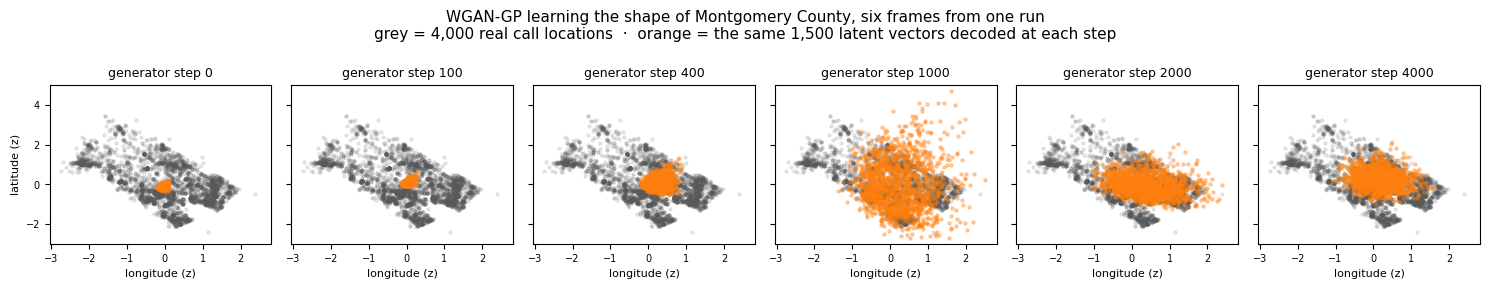

step    generated mean          generated std       max quadrant-share gap vs real
    0   (-0.06, -0.11)       (0.05, 0.08)        0.620
  100   (+0.03, +0.09)       (0.07, 0.10)        0.389
  400   (+0.23, +0.05)       (0.20, 0.27)        0.287
 1000   (+0.23, -0.02)       (0.63, 1.23)        0.092
 2000   (+0.39, -0.06)       (0.61, 0.51)        0.091
 4000   (+0.15, +0.26)       (0.43, 0.46)        0.226


In [3]:
# WHAT/WHY: the scatter above shows the finished fit. This is the same run as a
# storyboard — six frames of the generated cloud (orange) against the real 911
# call locations (grey), decoding the SAME 1,500 latent vectors each time.
# Frames come from the live generator; the scatter above used its EMA copy.
real_bg = sample_real(4000).numpy()
allp = np.vstack([p for _, p in snapshots_gp] + [real_bg])
lo, hi = allp.min(0) - 0.3, allp.max(0) + 0.3

fig, axes = plt.subplots(1, len(snapshots_gp), figsize=(15, 2.9), sharex=True, sharey=True)
for ax, (step, pts) in zip(axes, snapshots_gp):
    ax.scatter(real_bg[:, 0], real_bg[:, 1], s=5, alpha=0.12, c='0.35')
    ax.scatter(pts[:, 0], pts[:, 1], s=5, alpha=0.35, c='tab:orange')
    ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[1], hi[1])
    ax.set_title(f"generator step {step}", fontsize=9)
    ax.tick_params(labelsize=7)
    ax.set_xlabel("longitude (z)", fontsize=8)
axes[0].set_ylabel("latitude (z)", fontsize=8)
plt.suptitle("WGAN-GP learning the shape of Montgomery County, six frames from one run\n"
             "grey = 4,000 real call locations  ·  orange = the same 1,500 latent vectors decoded at each step",
             fontsize=11)
plt.tight_layout(); plt.show()

# ── Printed step table: coverage of the four quadrants, frame by frame ────
print("step    generated mean          generated std       max quadrant-share gap vs real")
for step, pts in snapshots_gp:
    gap = np.abs(real_share - quadrant_share(torch.tensor(pts))).max()
    print(f"{step:>5}   ({pts.mean(0)[0]:+.2f}, {pts.mean(0)[1]:+.2f})       "
          f"({pts.std(0)[0]:.2f}, {pts.std(0)[1]:.2f})        {gap:.3f}")

**Read the frames left to right.** At step 0 the untrained generator maps all 1,500 latent vectors into one small solid blob — printed standard deviations of about (0.05, 0.08) against the real (1.00, 1.00). The whole "distribution" is a dot. Through steps 100 and 400 that dot inflates in place; by step 1000 it has expanded across the county and *past* it, and the frames at 2000 and 4000 show the cloud sliding and re-spreading rather than sitting still. The printed table tracks it: the largest quadrant-share gap collapses from 0.631 to under 0.09, and the generated spread grows from (0.05, 0.08) to roughly (1.05, 0.92).

This is what a gradient penalty is *for*. The critic is unbounded — no sigmoid — so without the 1-Lipschitz constraint its gradients can grow without limit and this cloud would be flung around instead of converging. Six frames that expand and settle are evidence the constraint did its job, and it is evidence a loss curve cannot give you: the WGAN losses in the previous figure oscillate throughout and never announce that the cloud found the county.

Read the last frame critically too. The generator covers all four quadrants — no mode collapse — but it has learned a **smooth blob, not a county**. The real calls (grey) have hard structure: dense corridors, a jagged boundary, empty ground beyond it. The orange cloud spills past that boundary into places where nobody ever called, and it does not reproduce the dense interior corridors. That is the same shortfall the printed statistics report as an under-dispersed latitude and an over-weighted south-east quadrant, and the storyboard shows *where* on the map it happens, which no summary number can.

## 💬 Discuss

1. The generator covered all four county quadrants (**largest share gap 0.076**) but under-dispersed latitude (**std 0.896 against the real 1.000**) and over-weighted the south-east (**0.444 vs 0.367**). If this were a synthetic-911-data product sold to a dispatch-simulation vendor, would you ship it? Name the one extra test you would run before answering.
2. Lucic et al. found the tricks did not beat a plain GAN at matched compute — and we used a gradient penalty and still got an imperfect fit. Which experiment *in this notebook* would separate "the penalty didn't help" from "a 2-layer MLP is too small for this distribution"?
3. Mode coverage was measured by county quadrant, which was our choice. Propose a different partition of the map that would make this same generator look worse. Is your partition unfair — or is quadrant coverage simply too easy a test?


## Spectral Normalization, Measured Directly

Rather than folding spectral norm into the GAN above, we can measure exactly what it does: cap a layer's **largest singular value** (its Lipschitz constant) at ~1. Watch the printed value before and after.


In [4]:
# WHAT/WHY: show precisely what nn.utils.spectral_norm does — it divides the
# weight matrix by its largest singular value, capping the layer's Lipschitz
# constant at ~1. We print that value before and after wrapping the layer.
torch.manual_seed(1)

# ── A Linear layer with deliberately LARGE weights (Lipschitz >> 1) ───────
layer = nn.Linear(64, 64)
with torch.no_grad():
    layer.weight.mul_(5.0)                     # inflate the weights
sigma_before = torch.linalg.svdvals(layer.weight).max().item()
print(f"Largest singular value BEFORE spectral norm: {sigma_before:.3f}")

# ── Wrap with spectral_norm; a forward pass triggers the normalization ────
layer_sn = nn.utils.spectral_norm(layer)
for _ in range(5):
    _ = layer_sn(torch.randn(8, 64))           # power iteration refines the estimate
sigma_after = torch.linalg.svdvals(layer_sn.weight).max().item()
print(f"Largest singular value AFTER  spectral norm: {sigma_after:.3f}")

print("\nEvery forward pass re-normalizes the weights, so the critic's Lipschitz")
print("constant stays capped throughout training. SNGAN and BigGAN apply this to")
print("every discriminator layer as a drop-in stabilizer.")


Largest singular value BEFORE spectral norm: 5.547
Largest singular value AFTER  spectral norm: 1.032

Every forward pass re-normalizes the weights, so the critic's Lipschitz
constant stays capped throughout training. SNGAN and BigGAN apply this to
every discriminator layer as a drop-in stabilizer.


## ⚠️ Where this breaks

**The gradient penalty is sampled and soft.** It enforces ‖∇‖ ≈ 1 only on the interpolation line between the real and fake points you happened to draw, not everywhere in the input space. You get a much better-behaved critic; you do not get a guaranteed 1-Lipschitz one.

**Stacking the two stabilizers over-constrains a small critic** — which is why they are demonstrated separately here. Spectral norm caps *every* layer at ~1, and on a 2-layer critic that can leave too little capacity to separate the distributions at all.

**No stabilizer fixes insufficient capacity.** Latitude came out under-dispersed because a 2-layer MLP cannot bend to an irregular geographic distribution. Adding a third penalty will not change that; adding layers, data or training steps might.

**Cheaper alternative in 2026:** for a *new* generation project, a diffusion model trains stably under a plain MSE objective and needs none of this machinery. Reach for WGAN-GP when you are maintaining an existing GAN or when one-pass sampling speed is a hard requirement.


---

## 🔭 State of the field (2026)

*Enrichment, not examinable content — the official unit examines the technique above exactly as it is taught. This box says where that technique sits on the 2026 map.*

Two things happened to the stabilizer pile you just implemented. **Inside GANs**, a NeurIPS 2024 paper argues
the tricks were never necessary: it derives a regularized relativistic loss, proves local convergence for it —
which most relativistic losses do not admit — and uses that to discard the ad-hoc machinery and modernize the
backbone, reporting that the resulting minimalist R3GAN surpasses StyleGAN2 on FFHQ, ImageNet, CIFAR and
Stacked MNIST (Huang *et al.* 2025). **Outside GANs**, and more consequentially, the mainstream stopped playing
the min-max game altogether: flow matching trains a generator by regressing a target velocity field, so there is
no critic to keep in balance and no Lipschitz constraint to enforce in the first place (Lipman *et al.* 2024).

**Why these two techniques are still exactly the right thing to learn.** They are general tools that happen to
be taught on a GAN. The gradient penalty is how you learn to differentiate a loss with respect to its *input*
and feed that norm back into the objective — the same trick underlies adversarial-robustness training and
physics-informed losses. Spectral normalization is how you learn what a layer's largest singular value does to
a network, which is a fact about deep learning, not about GANs. And the diagnostic habit this notebook drills —
the loss curve said nothing happened, so you looked at the samples and found that something had — is the single
most transferable thing in the unit. The official plan examines both techniques.

**Read:** Huang *et al.* (2025), <https://arxiv.org/abs/2501.05441> · Lipman *et al.* (2024),
<https://arxiv.org/abs/2412.06264> (both listed below).

---

## 📚 References & Further Reading

**Papers:**
- Arjovsky et al. (2017) — [Wasserstein GAN](https://arxiv.org/abs/1701.07875)
- Gulrajani et al. (2017) — [Improved Training of Wasserstein GANs (WGAN-GP)](https://arxiv.org/abs/1704.00028)
- Miyato et al. (2018) — [Spectral Normalization for GANs](https://arxiv.org/abs/1802.05957)
- Salimans et al. (2016) — [Improved Techniques for Training GANs](https://arxiv.org/abs/1606.03498)
- Karras et al. (2020) — [Training Generative Adversarial Networks with Limited Data](https://arxiv.org/abs/2006.06676) *(StyleGAN2-ADA — the modern stabilization recipe when data is scarce)*

**In practice:** BigGAN, StyleGAN2, and most modern GANs ship with one or both of these constraints built in.

**Recent (2024–2026):**
- Huang et al. (2025) — [The GAN is dead; long live the GAN! A Modern GAN Baseline](https://arxiv.org/abs/2501.05441) *(NeurIPS 2024 — derives a well-behaved regularized relativistic loss with local convergence guarantees, then discards the ad-hoc tricks this notebook implements)*
- Lipman et al. (2024) — [Flow Matching Guide and Code](https://arxiv.org/abs/2412.06264) *(the other escape route: no critic, no Lipschitz constraint — training becomes regression onto a target velocity field)*
- Zhou et al. (2025) — [Terminal Velocity Matching](https://arxiv.org/abs/2511.19797) *(this notebook's Wasserstein-and-Lipschitz vocabulary in its post-GAN form: for Lipschitz continuous models the objective upper-bounds the 2-Wasserstein distance between data and model, reporting 3.29 FID with a single function evaluation on ImageNet 256×256)*


## 📝 Summary

In **08 — Training Techniques** you implemented the two standard GAN stabilizers: a **Wasserstein critic with gradient penalty** (computed with `torch.autograd.grad` on interpolated points) and **spectral normalization** (`nn.utils.spectral_norm`).

You verified both against measurements rather than claims:
- The WGAN-GP generator was trained to reproduce a **real, multi-modal distribution** — roughly 40,000 Montgomery County 911 call locations — and checked twice: its mean and standard deviation against the real data, and its **coverage of all four county quadrants**, which is the mode-collapse failure the gradient penalty exists to prevent. Both the printed shares and the scatter overlay show the generator spread across the real data (largest quadrant-share gap 0.076 — no collapse). The same numbers also show where it falls short: longitude spread is right (std 1.005 against the real 1.000) but latitude is under-dispersed (0.896), and the south-east quadrant — the dense Philadelphia-facing corner of the county — is over-weighted at 0.444 against a real 0.367. That is an honest, visible limitation of a 2-layer MLP on a real irregular distribution — and a single invented Gaussian target could not have exposed it.
- Spectral normalization measurably caps a layer's largest singular value at ~1 (printed before/after).

Why these help *in general* is the subject of the cited papers; try swapping the WGAN-GP loop into example 05's MNIST GAN as an experiment.
